# Sales Forescasting using ML (Linear Regression, Random Forest, XGBoost)
## Objective: To accurately forecast daily sales across restaurants using historical transaction data)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preliminary analysis:

In [2]:
items_df=pd.read_csv('/content/items.csv') # Items dataset
resturants_df=pd.read_csv('/content/resturants.csv') #resturants dataset
sales_df=pd.read_csv('/content/sales.csv') #sales dataset

In [3]:
print(items_df.shape)
print(resturants_df.shape)
print(sales_df.shape)

(100, 5)
(6, 2)
(109600, 4)


In [4]:
items_df.head(5) #This data contains information about items

,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


In [5]:
resturants_df.head(5) #This data provides information about the restaurants or store.

,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe


In [6]:
sales_df.head(5) #This contains the count of a particular item sold at a particular store or restaurant for different dates.

,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


# Merge the datsets

In [7]:
#rename the id column of items dataset with the same name as given in sales dataset
items_df.rename(columns={'id':'item_id'},inplace=True)


In [8]:
# Merge the item dataset with sales dataset
merged_df=pd.merge(sales_df,items_df,on='item_id')
merged_df.head(5)

,date,item_id,price,item_count,store_id,name,kcal,cost
0,2019-01-01,3,29.22,2.0,1,Sweet Fruity Cake,931,29.22
1,2019-01-01,4,26.42,22.0,1,Amazing Steak Dinner with Rolls,763,26.42
2,2019-01-01,12,4.87,7.0,1,Fantastic Sweet Cola,478,4.87
3,2019-01-01,13,4.18,12.0,1,Sweet Frozen Soft Drink,490,4.18
4,2019-01-01,16,3.21,136.0,1,Frozen Milky Smoothy,284,3.21


In [9]:
# Merge the result with restaurants on store_id

# rename the store id
resturants_df.rename(columns={'id':'store_id'},inplace=True)

final_df=pd.merge(merged_df,resturants_df,on='store_id')
final_df.head(5)

,date,item_id,price,item_count,store_id,name_x,kcal,cost,name_y
0,2019-01-01,3,29.22,2.0,1,Sweet Fruity Cake,931,29.22,Bob's Diner
1,2019-01-01,4,26.42,22.0,1,Amazing Steak Dinner with Rolls,763,26.42,Bob's Diner
2,2019-01-01,12,4.87,7.0,1,Fantastic Sweet Cola,478,4.87,Bob's Diner
3,2019-01-01,13,4.18,12.0,1,Sweet Frozen Soft Drink,490,4.18,Bob's Diner
4,2019-01-01,16,3.21,136.0,1,Frozen Milky Smoothy,284,3.21,Bob's Diner


In [10]:
# Rename the column names
final_df.rename(columns={'name_x':'item_name','name_y':'store_name','cost':'item_cost'},inplace=True)

In [11]:
final_df.head(5)

,date,item_id,price,item_count,store_id,item_name,kcal,item_cost,store_name
0,2019-01-01,3,29.22,2.0,1,Sweet Fruity Cake,931,29.22,Bob's Diner
1,2019-01-01,4,26.42,22.0,1,Amazing Steak Dinner with Rolls,763,26.42,Bob's Diner
2,2019-01-01,12,4.87,7.0,1,Fantastic Sweet Cola,478,4.87,Bob's Diner
3,2019-01-01,13,4.18,12.0,1,Sweet Frozen Soft Drink,490,4.18,Bob's Diner
4,2019-01-01,16,3.21,136.0,1,Frozen Milky Smoothy,284,3.21,Bob's Diner


In [12]:
final_df.columns

Index(['date', 'item_id', 'price', 'item_count', 'store_id', 'item_name',
       'kcal', 'item_cost', 'store_name'],
      dtype='object')

In [13]:
# extract two columns price and item_cost from df
final_df[['price','item_cost']]


,price,item_cost
0,29.22,29.22
1,26.42,26.42
2,4.87,4.87
3,4.18,4.18
4,3.21,3.21
...,...,...
109595,21.93,21.93
109596,28.65,28.65
109597,5.00,5.00
109598,5.32,5.32


Both columns are same. Let's drop any one of them.


In [14]:
final_df.drop('price',axis=1,inplace=True)

Total sale = Item cost * item count

In [15]:
final_df['Total_sale']=final_df['item_cost']*final_df['item_count']

In [16]:
final_df.head(5)

,date,item_id,item_count,store_id,item_name,kcal,item_cost,store_name,Total_sale
0,2019-01-01,3,2.0,1,Sweet Fruity Cake,931,29.22,Bob's Diner,58.44
1,2019-01-01,4,22.0,1,Amazing Steak Dinner with Rolls,763,26.42,Bob's Diner,581.24
2,2019-01-01,12,7.0,1,Fantastic Sweet Cola,478,4.87,Bob's Diner,34.09
3,2019-01-01,13,12.0,1,Sweet Frozen Soft Drink,490,4.18,Bob's Diner,50.16
4,2019-01-01,16,136.0,1,Frozen Milky Smoothy,284,3.21,Bob's Diner,436.56


In [17]:
final_df.shape

(109600, 9)

In [18]:
# Convert date to datetime format
final_df["date"] = pd.to_datetime(final_df["date"])

# Outlier detection

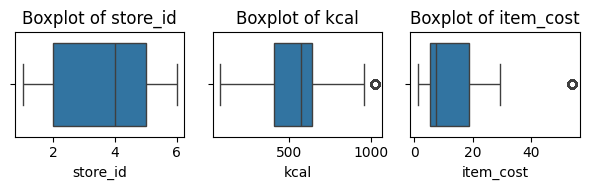

In [19]:
col=['store_id','kcal','item_cost']
fig, axes=plt.subplots(nrows=1,ncols=3,figsize=(6,2))
axes=axes.flatten()
for i,col in enumerate(col):
  if i<len(axes):
    sns.boxplot(data=final_df,x=col,ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [20]:
# Select only numerical columns
numerical_columns = ['item_count', 'store_id', 'kcal', 'item_cost', 'Total_sale']

# Dictionary to store outlier info
outlier_summary = {}

for col in numerical_columns:
    Q1 = final_df[col].quantile(0.25)
    Q3 = final_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Detect outliers
    outliers = (final_df[col] < lower_bound) | (final_df[col] > upper_bound)
    num_outliers = outliers.sum()
    outlier_percentage = (num_outliers / len(final_df)) * 100

    # Store in dictionary
    outlier_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': num_outliers,
        'Outlier Percentage': round(outlier_percentage, 2)
    }

# Display results in a tidy DataFrame
outlier_df = pd.DataFrame(outlier_summary).T  # Transpose for readability
print(outlier_df)


                Q1      Q3     IQR  Lower Bound  Upper Bound  \
item_count    0.00    0.00    0.00        0.000        0.000   
store_id      2.00    5.00    3.00       -2.500        9.500   
kcal        406.25  638.25  232.00       58.250      986.250   
item_cost     5.28   18.79   13.51      -14.985       39.055   
Total_sale    0.00    0.00    0.00        0.000        0.000   

            Number of Outliers  Outlier Percentage  
item_count             23484.0               21.43  
store_id                   0.0                0.00  
kcal                    1096.0                1.00  
item_cost               1096.0                1.00  
Total_sale             23484.0               21.43  


**Outliers in item_count and Total_sale:**

Outlier Count: 23,484 entries (~21.43% of total data)

If Q1 = Q3 = 0, it implies that at least 75% of the data values are zero.

So, any value ≠ 0 is  considered as an outlier under the IQR method.

But the item count ≠ 0, would be the meaningful data, no need to remove these outliers.

# Exploratory data analysis

Overall sales to understand the pattern

In [21]:
final_df.head()

,date,item_id,item_count,store_id,item_name,kcal,item_cost,store_name,Total_sale
0,2019-01-01,3,2.0,1,Sweet Fruity Cake,931,29.22,Bob's Diner,58.44
1,2019-01-01,4,22.0,1,Amazing Steak Dinner with Rolls,763,26.42,Bob's Diner,581.24
2,2019-01-01,12,7.0,1,Fantastic Sweet Cola,478,4.87,Bob's Diner,34.09
3,2019-01-01,13,12.0,1,Sweet Frozen Soft Drink,490,4.18,Bob's Diner,50.16
4,2019-01-01,16,136.0,1,Frozen Milky Smoothy,284,3.21,Bob's Diner,436.56


# Sales fluctuation  across different days of the week

In [49]:
from typing_extensions import final
final_df['day']=final_df['date'].dt.day
final_df['day_of_week']=final_df['date'].dt.day_name()
final_df['year']=final_df['date'].dt.year
final_df['month']=final_df['date'].dt.month
final_df.head()

,date,item_id,item_count,store_id,item_name,kcal,item_cost,store_name,Total_sale,day_of_week,year,month,quarter,day
0,2019-01-01,3,2.0,1,Sweet Fruity Cake,931,29.22,Bob's Diner,58.44,Tuesday,2019,1,1,1
1,2019-01-01,4,22.0,1,Amazing Steak Dinner with Rolls,763,26.42,Bob's Diner,581.24,Tuesday,2019,1,1,1
2,2019-01-01,12,7.0,1,Fantastic Sweet Cola,478,4.87,Bob's Diner,34.09,Tuesday,2019,1,1,1
3,2019-01-01,13,12.0,1,Sweet Frozen Soft Drink,490,4.18,Bob's Diner,50.16,Tuesday,2019,1,1,1
4,2019-01-01,16,136.0,1,Frozen Milky Smoothy,284,3.21,Bob's Diner,436.56,Tuesday,2019,1,1,1


In [50]:
# Define the order of weekdays
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group by day_of_week and sum total sales
daily_sales = final_df.groupby('day_of_week')['Total_sale'].sum().reset_index()

# Convert day_of_week to a categorical type with defined order
daily_sales['day_of_week'] = pd.Categorical(daily_sales['day_of_week'], categories=weekday_order, ordered=True)

# Sort by the ordered categorical day_of_week
daily_sales = daily_sales.sort_values('day_of_week')

# Display the sorted DataFrame
daily_sales

,day_of_week,Total_sale
1,Monday,644799.97
5,Tuesday,734598.46
6,Wednesday,812613.31
4,Thursday,1073534.52
0,Friday,1257338.16
2,Saturday,1250574.32
3,Sunday,630279.71


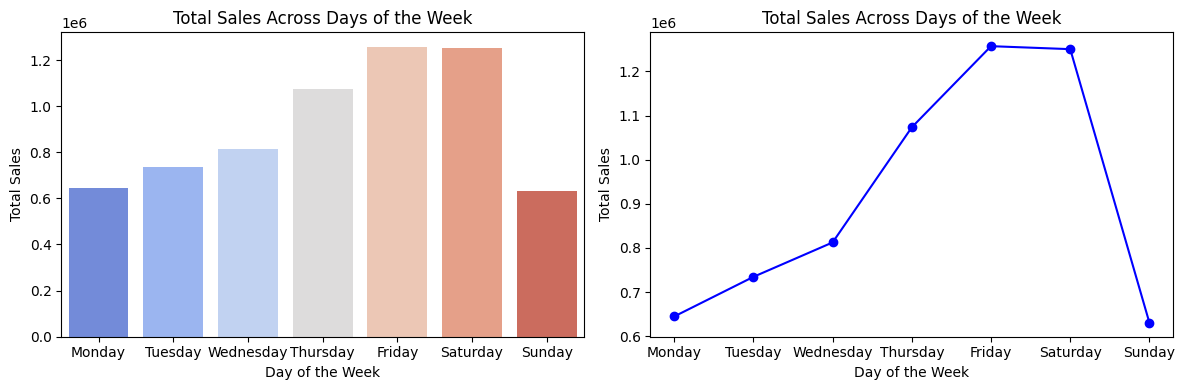

In [51]:
# Create a single figure with two subplots in one row
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # One row, two columns

# First subplot: Bar plot
sns.barplot(data=daily_sales, x='day_of_week', y='Total_sale', palette="coolwarm", ax=axes[0])
axes[0].set_title("Total Sales Across Days of the Week")
axes[0].set_xlabel("Day of the Week")
axes[0].set_ylabel("Total Sales")

# Second subplot: Line plot
axes[1].plot(daily_sales['day_of_week'], daily_sales['Total_sale'], marker='o', linestyle='-', color='b')
axes[1].set_title("Total Sales Across Days of the Week")
axes[1].set_xlabel("Day of the Week")
axes[1].set_ylabel("Total Sales")

plt.tight_layout()
plt.show()


Sales activity peaks on Thursdays, Fridays, and Saturdays, indicating these days as the most profitable in terms of revenue generation.

# **Trends in the sales data for different months of the year**

In [52]:
final_df['year'].unique()

array([2019, 2020, 2021], dtype=int32)

In [53]:
# Group by year and month number for a multi-line trend across years
monthly_sales_by_year = final_df.groupby(["year", "month"])["Total_sale"].sum().unstack()
monthly_sales_by_year

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2019,109759.77,114960.23,151744.62,165548.24,201332.60,202030.12,202401.49,192296.76,157886.74,141260.25,123750.59,108790.90
2020,121461.34,134155.80,160419.90,185154.79,218102.43,232658.15,229253.18,219967.33,188612.31,173257.91,138477.24,132160.40
2021,144556.91,145411.35,186054.37,220755.36,246628.14,256427.79,274384.12,234760.88,202428.34,186774.05,150308.03,149806.02


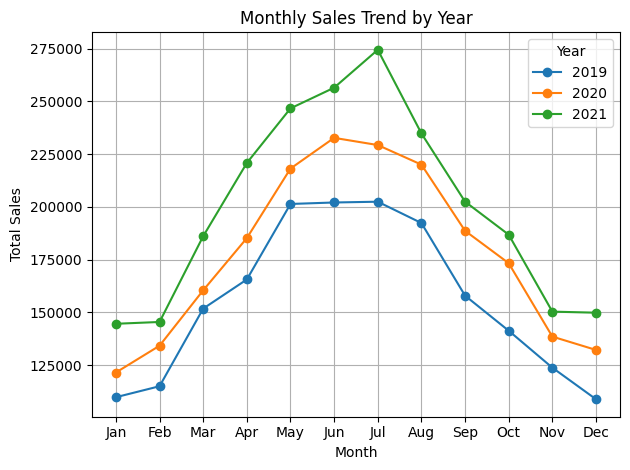

In [54]:
# Plot multi-line chart
import calendar


month_labels = list(calendar.month_abbr[1:])  # Define month labels using calendar module

for year in monthly_sales_by_year.index:
    plt.plot(month_labels, monthly_sales_by_year.loc[year], marker='o', label=str(year))

plt.title("Monthly Sales Trend by Year")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend(title="Year")
plt.grid('True')
plt.tight_layout()
plt.show()

Each year, sales show a consistent upward trend from February to July, with June and July marking the peak months. Following this period, sales begin to decline.

# **Sales distribution across different quarters averaged over the years.**

In [55]:
# Ensure quarter column is present
final_df["quarter"] = final_df["date"].dt.quarter

# Group by year and quarter, then compute total sales
quarterly_sales = final_df.groupby(["year", "quarter"])["Total_sale"].sum().unstack()
quarterly_sales

quarter,1,2,3,4
year,,,,
2019,376464.62,568910.96,552584.99,373801.74
2020,416037.04,635915.37,637832.82,443895.55
2021,476022.63,723811.29,711573.34,486888.10


In [56]:
# Calculate average sales per quarter across years
average_quarterly_sales = quarterly_sales.mean()
average_quarterly_sales

,0
quarter,
1,422841.430000
2,642879.206667
3,633997.050000
4,434861.796667


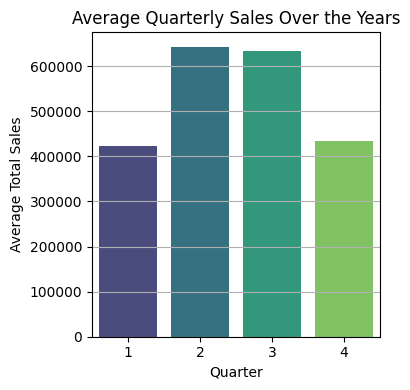

In [57]:
# Plot the average sales per quarter
plt.figure(figsize=(4, 4))
sns.barplot(x=average_quarterly_sales.index, y=average_quarterly_sales.values, palette="viridis")
plt.title("Average Quarterly Sales Over the Years")
plt.xlabel("Quarter")
plt.ylabel("Average Total Sales")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Insights:

Q2 and Q3 show significantly higher average sales.

Q1 and Q4 are relatively low in comparison.

This suggests a strong seasonal pattern where sales peak mid-year and dip in the beginning and end.


# Compare the performances of the different restaurants. Find out which restaurant had the most sales and look at the sales for each restaurant across different years, months, and days.

In [58]:
# Total sales by restuarants
total_sales_by_rest=final_df.groupby('store_name')['Total_sale'].sum().reset_index()
total_sales_by_rest = total_sales_by_rest.sort_values(by='Total_sale', ascending=False)
total_sales_by_rest

,store_name,Total_sale
1,Bob's Diner,6337275.69
3,Fou Cher,27885.37
2,Corner Cafe,16551.43
4,Surfs Up,15651.49
0,Beachfront Bar,3796.20
5,Sweet Shack,2578.27


In [59]:
import warnings
warnings.filterwarnings("ignore")

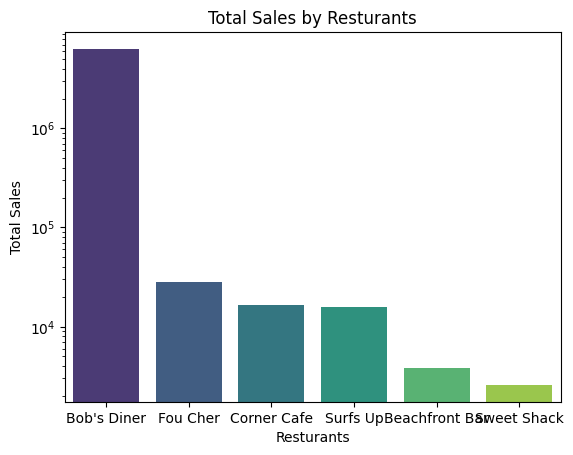

In [60]:
#Plot total sales by resturants
sns.barplot(data=total_sales_by_rest,x='store_name',y='Total_sale',palette='viridis')
plt.title('Total Sales by Resturants')
plt.xlabel('Resturants')
plt.ylabel('Total Sales')
plt.yscale('log') #to compress large values and expand smaller ones--for better visualozation
plt.show()

In [61]:
# year-wise sales by restaurants

sales_by_year=final_df.groupby(['year','store_name'])['Total_sale'].sum().unstack()
sales_by_year

store_name,Beachfront Bar,Bob's Diner,Corner Cafe,Fou Cher,Surfs Up,Sweet Shack
year,,,,,,
2019,1281.85,1849483.49,5292.93,9698.80,5132.65,872.59
2020,1267.21,2112331.91,5347.71,8590.87,5314.43,828.65
2021,1247.14,2375460.29,5910.79,9595.70,5204.41,877.03


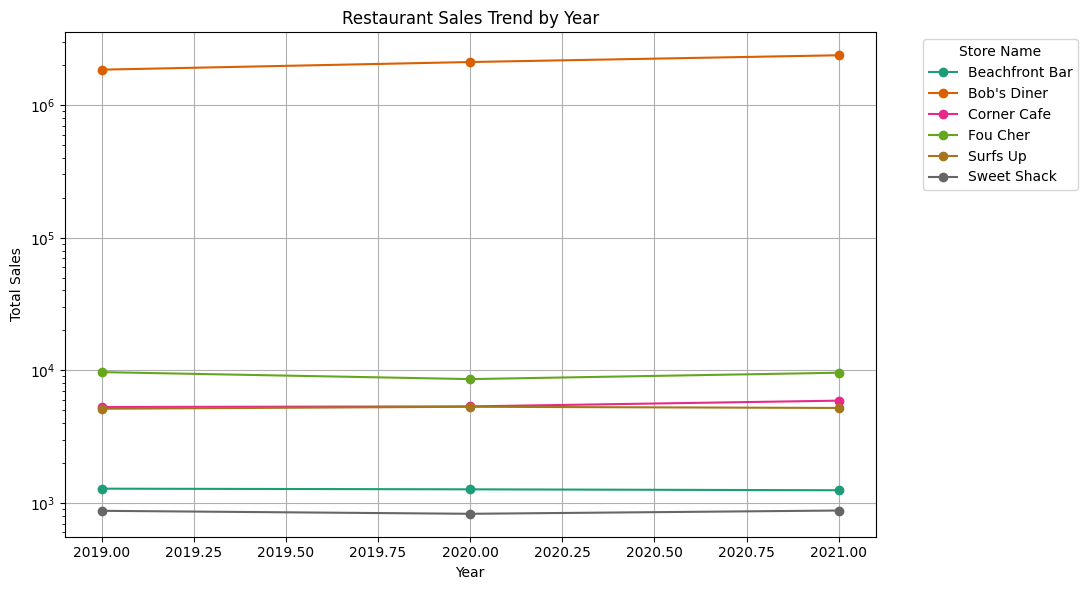

In [62]:
sales_by_year.plot(kind='line', marker='o', figsize=(11, 6), colormap='Dark2')

plt.title('Restaurant Sales Trend by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.yscale('log')
plt.grid(True)
plt.legend(title='Store Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Bob's Dinner sales increased from 2019 to 2021.

Surfs Up , Beachfront Bar and Swwet shack shows steady growth.

Fou Cher and 	Corner Cafe shows a drop in sales in 2020 and then again retain it's growth in 2021.


In [63]:
# month wise sales by resturants
sales_by_month=final_df.groupby(['month','store_name'])['Total_sale'].sum().unstack()
sales_by_month

store_name,Beachfront Bar,Bob's Diner,Corner Cafe,Fou Cher,Surfs Up,Sweet Shack
month,,,,,,
1,315.55,370097.57,1055.98,2843.70,1210.82,254.40
2,318.10,389551.18,1241.46,1697.06,1537.97,181.61
3,340.23,492825.83,1335.54,2417.40,1083.98,215.91
4,317.58,565964.33,1394.36,2342.80,1247.49,191.83
5,332.64,659818.97,1370.26,2782.85,1523.98,234.47
6,293.06,685615.82,1545.99,2212.31,1222.15,226.73
7,299.07,701013.00,1318.82,1833.98,1368.05,205.87
8,284.38,641471.70,1524.04,2001.18,1523.90,219.77
9,305.71,543733.47,1445.54,2008.27,1220.34,214.06


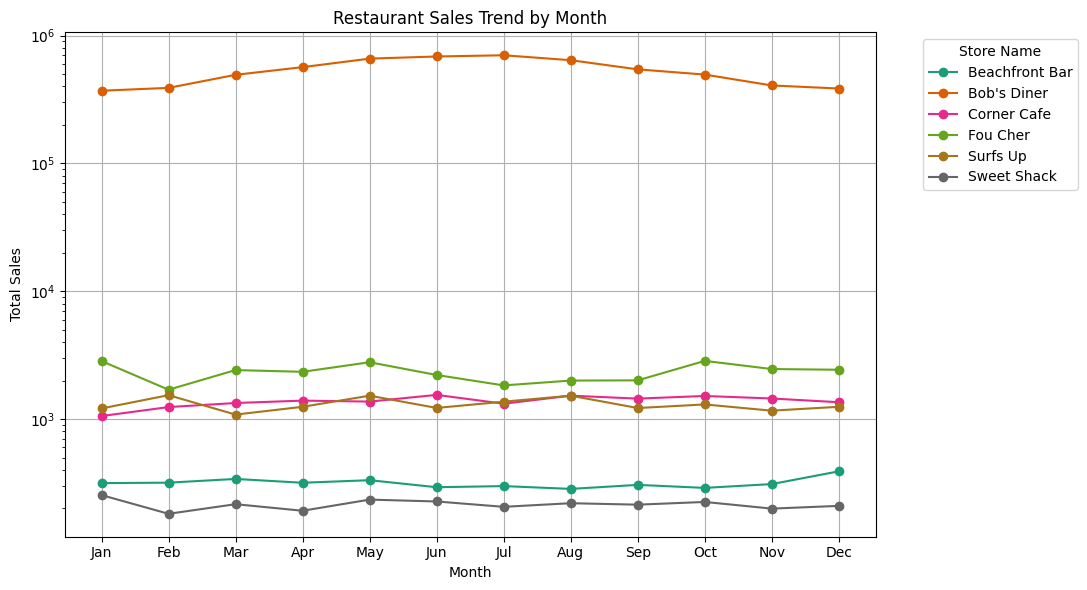

In [64]:
# plot month wise sales by restaurants
sales_by_month.plot(kind='line', marker='o', figsize=(11, 6), colormap='Dark2')
plt.title('Restaurant Sales Trend by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.yscale('log')
plt.xticks(range(1, 13),labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True)
plt.legend(title='Store Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Peak Sales Months by Restaurant:

Bob's Diner: May to August

Fou Cher: January, May, and October

Surfs Up: February, May, and August

Corner Cafe: June

Beachfront Bar: December

Sweet Shack: June

In [65]:
# Define the correct order for weekdays
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

#Calculate the sales by weekday
sales_by_weekday = final_df.groupby('day_of_week')['Total_sale'].sum()

# Convert index to ordered categorical
sales_by_weekday.index = pd.CategoricalIndex(sales_by_weekday.index, categories=weekday_order, ordered=True)

# Sort the DataFrame by this new index
sales_by_weekday = sales_by_weekday.sort_index()
sales_by_weekday

,Total_sale
day_of_week,
Monday,644799.97
Tuesday,734598.46
Wednesday,812613.31
Thursday,1073534.52
Friday,1257338.16
Saturday,1250574.32
Sunday,630279.71


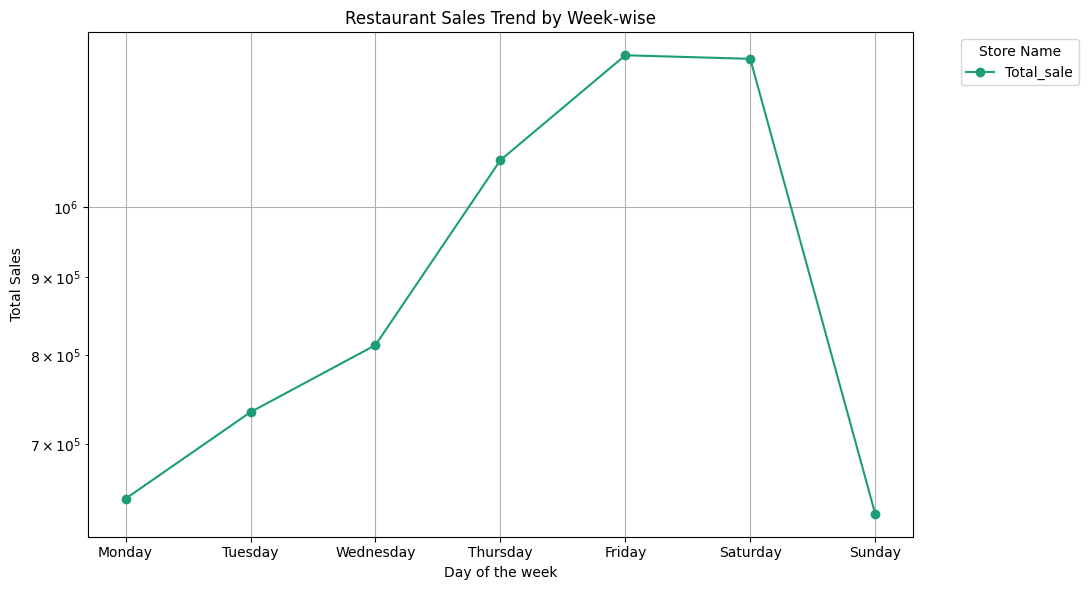

In [66]:
# Plot weekday-wise sales by restuarants
sales_by_weekday.plot(kind='line', marker='o', figsize=(11, 6), colormap='Dark2')
plt.title('Restaurant Sales Trend by Week-wise')
plt.xlabel('Day of the week')
plt.ylabel('Total Sales')
plt.yscale('log')
plt.grid(True)
plt.legend(title='Store Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The most popular items overall and the stores (by qty sold) where they are being sold:

In [67]:
final_df.columns

Index(['date', 'item_id', 'item_count', 'store_id', 'item_name', 'kcal',
       'item_cost', 'store_name', 'Total_sale', 'day_of_week', 'year', 'month',
       'quarter', 'day'],
      dtype='object')

In [68]:
popular_items=final_df.groupby('item_name')['item_count'].sum().sort_values(ascending=False)
popular_items=popular_items[popular_items>0]
popular_items

,item_count
item_name,
Strawberry Smoothy,236337.0
Frozen Milky Smoothy,103263.0
Amazing pork lunch,61043.0
Mutton Dinner,52772.0
Orange Juice,43874.0
...,...
Amazing Sweet Breaded Carrot Cake,2.0
Amazing Vegetable and Bread Dinner,1.0
Original Sweet Milky Soft Drink,1.0


In [69]:
## Stores where these items are being sold
popular_items_stores=final_df.groupby(['store_name','item_name'])['item_count'].sum().sort_values(ascending=False)
popular_items_stores=popular_items_stores[popular_items_stores>0]
popular_items_stores

store_name   item_name                         
Bob's Diner  Strawberry Smoothy                    236337.0
             Frozen Milky Smoothy                  102990.0
             Amazing pork lunch                     61043.0
             Mutton Dinner                          52772.0
             Orange Juice                           43874.0
                                                     ...   
Corner Cafe  Amazing Sweet Breaded Carrot Cake          2.0
Sweet Shack  Original Sweet Milky Soft Drink            1.0
Fou Cher     Fruity Milky Cake                          1.0
             Amazing Vegetable and Bread Dinner         1.0
             Chocolate Cake                             1.0
Name: item_count, Length: 92, dtype: float64

In [70]:
# The most popular item at each store
most_popular_item_by_store = popular_items_stores.groupby('store_name').idxmax()

# Convert to DataFrame and reset index for better readability
most_popular_item_by_store = most_popular_item_by_store.reset_index()
most_popular_item_by_store.columns = ['store_name', 'item_name']

most_popular_item_by_store

,store_name,item_name
0,Beachfront Bar,"(Beachfront Bar, Fantastic Milky Smoothy)"
1,Bob's Diner,"(Bob's Diner, Strawberry Smoothy)"
2,Corner Cafe,"(Corner Cafe, Frozen Milky Smoothy)"
3,Fou Cher,"(Fou Cher, Blue Ribbon Fruity Vegi Lunch)"
4,Surfs Up,"(Surfs Up, Awesome Soft Drink)"
5,Sweet Shack,"(Sweet Shack, Awesome Smoothy)"


# Determine if the store with the highest sales volume is also making the most money per day

In [71]:
# Step: Compare store-wise sales volume vs revenue

# Total item count (volume) and total revenue by store
store_volume = final_df.groupby("store_name")["item_count"].sum()
store_revenue = final_df.groupby("store_name")["Total_sale"].sum()

# Average revenue per day per store
daily_revenue_per_store = final_df.groupby(["store_name", "date"])["Total_sale"].sum().reset_index()
avg_daily_revenue = daily_revenue_per_store.groupby("store_name")["Total_sale"].mean().sort_values(ascending=False)

# Combine metrics into one summary table
store_analysis = pd.DataFrame({
    "Total Volume Sold": store_volume,
    "Total Revenue": store_revenue,
    "Average Daily Revenue": avg_daily_revenue
}).sort_values(by="Total Volume Sold", ascending=False)

store_analysis

,Total Volume Sold,Total Revenue,Average Daily Revenue
store_name,,,
Bob's Diner,687527.0,6337275.69,5782.185849
Surfs Up,1803.0,15651.49,14.280557
Sweet Shack,1736.0,2578.27,2.352436
Corner Cafe,1310.0,16551.43,15.101670
Beachfront Bar,1305.0,3796.20,3.463686
Fou Cher,1106.0,27885.37,25.442856


Bob's Dinner has the highest sale volume and the highest revenue per day confirming that it is the most profitable restaurant.

# The most expensive item at each restaurant and its calorie count

In [72]:
# Find the most expensive item at each store
most_expensive_per_store = final_df.loc[final_df.groupby("store_name")["item_cost"].idxmax()][["store_name", "item_name", "item_cost", "kcal"]]
most_expensive_per_store.rename(columns={"item_name": "Item Name", "item_cost": "Cost", "kcal": "Calories"}, inplace=True)

most_expensive_per_store.sort_values(by="Cost", ascending=False)

,store_name,Item Name,Cost,Calories
82,Fou Cher,Blue Ribbon Fruity Vegi Lunch,53.98,881
0,Bob's Diner,Sweet Fruity Cake,29.22,931
58,Corner Cafe,Pike Lunch,26.37,653
8,Surfs Up,Steak Meal,26.21,607
79,Sweet Shack,Blue Ribbon Frozen Milky Cake,7.70,636
68,Beachfront Bar,Sweet Vegi Soft Drink,5.70,538


# Forecasting using machine learning algorithms:

In [73]:
final_df.head(5)

,date,item_id,item_count,store_id,item_name,kcal,item_cost,store_name,Total_sale,day_of_week,year,month,quarter,day
0,2019-01-01,3,2.0,1,Sweet Fruity Cake,931,29.22,Bob's Diner,58.44,Tuesday,2019,1,1,1
1,2019-01-01,4,22.0,1,Amazing Steak Dinner with Rolls,763,26.42,Bob's Diner,581.24,Tuesday,2019,1,1,1
2,2019-01-01,12,7.0,1,Fantastic Sweet Cola,478,4.87,Bob's Diner,34.09,Tuesday,2019,1,1,1
3,2019-01-01,13,12.0,1,Sweet Frozen Soft Drink,490,4.18,Bob's Diner,50.16,Tuesday,2019,1,1,1
4,2019-01-01,16,136.0,1,Frozen Milky Smoothy,284,3.21,Bob's Diner,436.56,Tuesday,2019,1,1,1


In [100]:
#Features and Target

X = final_df[["day", "month", "quarter", "year"]]
y = final_df["Total_sale"]

In [101]:
# Train-test split (Last 6 months as test)
cutoff_date=final_df['date'].max()-pd.DateOffset(months=6)
X_train=X[final_df['date']<=cutoff_date]
y_train=y[final_df['date']<=cutoff_date]
X_test=X[final_df['date']>cutoff_date]
y_test=y[final_df['date']>cutoff_date]

In [102]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

In [103]:
# Models
lr=LinearRegression()
rf=RandomForestRegressor(random_state=42)
xgb=XGBRegressor(random_state=42, Objective='reg:squarederror')

In [104]:
#Training
lr.fit(X_train,y_train)
rf.fit(X_train,y_train)
xgb.fit(X_train,y_train)

XGBRegressor(Objective='reg:squarederror', base_score=None, booster=None,
             callbacks=None, colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, ...)

In [105]:
#Predictions
lr_pred=lr.predict(X_test)
rf_pred=rf.predict(X_test)
xgb_pred=xgb.predict(X_test)

In [106]:
#RMSE
lr_rmse=np.sqrt(mean_squared_error(y_test,lr_pred))
rf_rmse=np.sqrt(mean_squared_error(y_test,rf_pred))
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

In [107]:
print("Linear Regression RMSE:", lr_rmse)
print("Random Forest RMSE:", rf_rmse)
print("XGBoost RMSE:", xgb_rmse)

Linear Regression RMSE: 237.46728203072408
Random Forest RMSE: 237.12504930376048
XGBoost RMSE: 237.28509782036897


Random Forest is the best performer here based on RMSE

In [110]:
# Forecasting Next year (Using Best Model)
future_dates=pd.date_range(start=final_df["date"].max() + pd.Timedelta(days=1), periods=365)
future_df = pd.DataFrame({ "date": future_dates,
                          "day": future_dates.day,
                           "month": future_dates.month,
                           "quarter": future_dates.quarter,
                           "year": future_dates.year })

In [111]:
future_df

,date,day,month,quarter,year
0,2022-01-01,1,1,1,2022
1,2022-01-02,2,1,1,2022
2,2022-01-03,3,1,1,2022
3,2022-01-04,4,1,1,2022
4,2022-01-05,5,1,1,2022
...,...,...,...,...,...
360,2022-12-27,27,12,4,2022
361,2022-12-28,28,12,4,2022
362,2022-12-29,29,12,4,2022
363,2022-12-30,30,12,4,2022


In [112]:
#Predict with RandomFOrest
future_df["predicted_sales"] = xgb.predict(future_df[["day", "month", "quarter", "year"]])

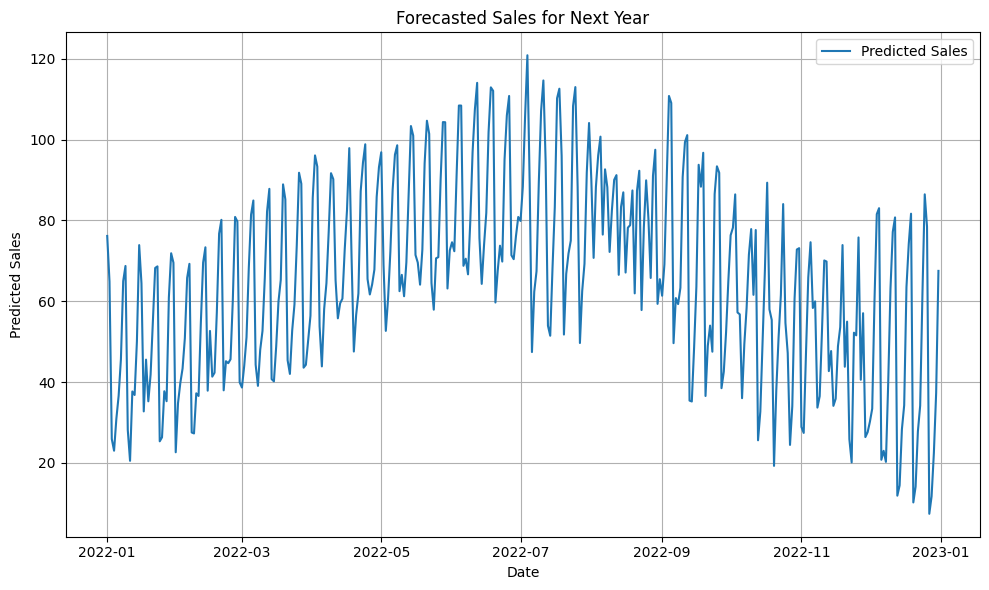

In [117]:
#Plotting the forecast

plt.figure(figsize=(10, 6))
plt.plot(future_df["date"], future_df["predicted_sales"], label="Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.title("Forecasted Sales for Next Year")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [118]:
#save to csv
future_df.to_csv('forecast_next_year.csv',index=False)